# Dyad Learning Experiment

## Research Question
**Is learning in a dyad beneficial for the learning process of a reinforcement learning agent?**

## Setup
- **Environment**: Netslide puzzle from Simon Tatham's Portable Puzzle Collection (Gymnasium + Pygame + C backend)
- **Puzzle params**: `2x3b1` (small) and `3x3b1` (medium)
- **Algorithm**: DQN with experience replay, target network, and action masking
- **Observations**: Discrete internal game state (MLP agent) or RGB pixels (CNN agent)
- **Config**: Hydra YAML configs under `config/`; experiment presets under `config/experiment/`

## Experiments
| # | Name | Agent | Obs Type | Config |
|---|------|-------|----------|--------|
| 1 | Baseline MLP | MLP DQN | Discrete state | `+experiment=baseline_mlp` |
| 2 | Baseline CNN | CNN DQN | RGB pixels | `+experiment=baseline_cnn` |
| 3 | Dyad Learning | MLP + CNN | Both (shared) | `+experiment=dyad` |

## Outputs
- **Checkpoints**: `checkpoints/{experiment_name}/`
- **Training CSV**: `results/{experiment_name}/{agent}_training.csv`
- **Eval JSON**: `results/{experiment_name}/{agent}_eval.json`
- **Plots**: Generated inline below

## 0. Imports & Setup

In [2]:
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np

from evaluation.analyze import (
    load_training_csv,
    load_eval_json,
    smooth,
    plot_learning_curves,
    plot_eval_comparison,
)

# Ensure plots render inline
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

print("Imports OK")

Imports OK


## 1. Environment Sanity Check

### Vectorized Environment Test

Quick verification that the environment loads and responds to actions for vectorized state-space (`puzzle_state`).

In [ ]:
import gymnasium as gym
import rlp  # registers rlp/Puzzle-v0

env = gym.make(
    "rlp/Puzzle-v0",
    puzzle="netslide",
    render_mode="rgb_array",
    params="2x3b1",
    window_width=128,
    window_height=128,
    obs_type="puzzle_state",
    include_cursor_in_state_info=True,
)

obs, info = env.reset(seed=42)
print(f"Obs space:    {env.observation_space}")
print(f"Action space: {env.action_space} ({env.action_space.n} actions)")
print(f"Obs keys:     {list(obs.keys())}")
print(f"Info keys:    {list(info.keys())}")
print(f"Action mask:  {env.unwrapped.action_masks()}")

# Take a few random steps
for i in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"  Step {i+1}: action={action}, reward={reward}, done={terminated or truncated}")
    print(f"Observation state: {obs}")
    if terminated or truncated:
        obs, info = env.reset()

env.close()
print("Environment OK")

Obs space:    Dict('barriers': Box(0, 256, (6,), uint16), 'cursor_pos': Box(-1, 3, (2,), int32), 'height': Discrete(3, start=1), 'last_move_col': Discrete(3, start=-1), 'last_move_dir': Discrete(4, start=-1), 'last_move_row': Discrete(4, start=-1), 'move_count': Box(0, 2147483647, (1,), int32), 'movetarget': Box(0, 2147483647, (1,), int32), 'tiles': Box(0, 31, (6,), uint16), 'width': Discrete(2, start=1), 'wrapping': Discrete(2))
Action space: Discrete(5) (5 actions)
Obs keys:     ['width', 'height', 'wrapping', 'move_count', 'movetarget', 'last_move_row', 'last_move_col', 'last_move_dir', 'tiles', 'barriers', 'cursor_pos']
Info keys:    ['puzzle_state', 'state_histogram', 'current_state_repeats', 'current_move_was_toward_solution', 'current_move_was_cursor_move']
Action mask:  [0 1 1 1 1]
  Step 1: action=0, reward=0, done=False
Observation state: {'width': 2, 'height': 3, 'wrapping': 0, 'move_count': array([0], dtype=int32), 'movetarget': array([0], dtype=int32), 'last_move_row': -1,

: 

### RGB Environment Test

Quick verification that the environment loads and responds to actions for vectorized state-space (`rgb`).

In [ ]:

import gymnasium as gym
import rlp  # registers rlp/Puzzle-v0

env = gym.make(
    "rlp/Puzzle-v0",
    puzzle="netslide",
    render_mode="rgb_array",
    params="2x3b1",
    window_width=128,
    window_height=128,
    obs_type="rgb",
    include_cursor_in_state_info=True,
)

obs, info = env.reset(seed=42)
print(f"Obs space:    {env.observation_space}")
print(f"Action space: {env.action_space} ({env.action_space.n} actions)")
print(f"Obs keys:     {list(obs.keys())}")
print(f"Info keys:    {list(info.keys())}")
print(f"Action mask:  {env.unwrapped.action_masks()}")

# Take a few random steps
for i in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"  Step {i+1}: action={action}, reward={reward}, done={terminated or truncated}")
    print(f"Observation state: {obs}")
    if terminated or truncated:
        obs, info = env.reset()

env.close()
print("Environment OK")

### Dual Observation Test

In [ ]:

import gymnasium as gym
import rlp  # registers rlp/Puzzle-v0

env = gym.make(
    "rlp/Puzzle-v0",
    puzzle="netslide",
    render_mode="rgb_array",
    params="2x3b1",
    window_width=128,
    window_height=128,
    obs_type="dual",
    include_cursor_in_state_info=True,
)

obs, info = env.reset(seed=42)
print(f"Obs space:    {env.observation_space}")
print(f"Action space: {env.action_space} ({env.action_space.n} actions)")
print(f"Obs keys:     {list(obs.keys())}")
print(f"Info keys:    {list(info.keys())}")
print(f"Action mask:  {env.unwrapped.action_masks()}")

# Take a few random steps
for i in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"  Step {i+1}: action={action}, reward={reward}, done={terminated or truncated}")
    print(f"Observation state: {obs}")
    if terminated or truncated:
        obs, info = env.reset()

env.close()
print("Environment OK")

Obs space:    Dict('pixels': Box(0, 255, (3, 128, 128), uint8), 'puzzle_state': Box(-inf, inf, (34,), float32))
Action space: Discrete(5) (5 actions)
Obs keys:     ['puzzle_state', 'pixels']
Info keys:    ['puzzle_state', 'state_histogram', 'current_state_repeats', 'current_move_was_toward_solution', 'current_move_was_cursor_move']
Action mask:  [0 1 1 1 1]
  Step 1: action=0, reward=0, done=False
Observation state: {'puzzle_state': array([126., 179., 102., 153., 236., 219.,   0.,  -1.,   0.,   0.,   1.,
         1.,   0.,   0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,   0.,
         0.,   0.,   9.,  12.,   3.,   6.,   4.,   1.,   0.,   1.,   1.,
         0.], dtype=float32), 'pixels': array([[[229, 229, 229, ...,   0,   0,   0],
        [229, 229, 229, ...,   0,   0,   0],
        [229, 229, 229, ...,   0,   0,   0],
        ...,
        [229, 229, 229, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[229, 229, 

---
## 1.4 Observation Pipeline Deep-Check

Verifies the full observation pipeline from environment output through wrappers to agent input:
- Shapes, dtypes, and value ranges for each obs mode
- Normalization correctness (puzzle_state → [-1,1], RGB → [0,1])
- Dual-mode field consistency (both modalities match the puzzle state)
- `process_obs()` routing correctness for each agent type
- Replay buffer round-trip fidelity
- Agent `select_action` input compatibility (no NaN/Inf, correct shape/dtype)

In [15]:
"""Deep check of the observation pipeline."""
import numpy as np
import torch
import gymnasium as gym
from gymnasium.wrappers import FlattenObservation

import rlp  # noqa
from utils.env_factory import make_env, make_dual_obs_env
from utils.obs_processing import process_obs, normalize_rgb, NormalizePuzzleStateWrapper
from omegaconf import OmegaConf

# ── Minimal config for the tests ──────────────────────────────────────────────
cfg = OmegaConf.create({
    "env": {
        "puzzle": "netslide",
        "params": "2x3b1",
        "obs_type": "puzzle_state",
        "render_mode": "rgb_array",
        "window_width": 128,
        "window_height": 128,
        "allow_undo": False,
        "max_state_repeats": 200,
        "include_cursor_in_state_info": True,
    }
})

PASS = "✅ PASS"
FAIL = "❌ FAIL"

def check(label, condition, detail=""):
    status = PASS if condition else FAIL
    print(f"{status}  {label}" + (f"  [{detail}]" if detail else ""))
    return condition

all_ok = True

# ─────────────────────────────────────────────────────────────────────────────
# 1. puzzle_state single-modality env
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 1. puzzle_state single-modality (make_env) ──────────────────────────")
cfg_ps = OmegaConf.merge(cfg, {"env": {"obs_type": "puzzle_state"}})
env_ps = make_env(cfg_ps)
obs_ps, _ = env_ps.reset(seed=0)

all_ok &= check("obs is 1-D ndarray",     obs_ps.ndim == 1,                      f"ndim={obs_ps.ndim}")
all_ok &= check("obs dtype float32",       obs_ps.dtype == np.float32,            f"dtype={obs_ps.dtype}")
all_ok &= check("obs values in [-1, 1]",   obs_ps.min() >= -1.0 and obs_ps.max() <= 1.0,
                                            f"min={obs_ps.min():.3f}, max={obs_ps.max():.3f}")
all_ok &= check("action_masks accessible", len(env_ps.action_masks()) == env_ps.action_space.n)

# process_obs routing
agent_obs, sd, sr = process_obs(obs_ps, "puzzle_state", dual_obs=False)
all_ok &= check("process_obs: agent_obs == obs",  np.array_equal(agent_obs, obs_ps))
all_ok &= check("process_obs: state_discrete is None (non-dual)", sd is None)
all_ok &= check("process_obs: state_rgb is None (non-dual)",      sr is None)

# ─────────────────────────────────────────────────────────────────────────────
# 2. RGB single-modality env
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 2. RGB single-modality (make_env) ───────────────────────────────────")
cfg_rgb = OmegaConf.merge(cfg, {"env": {"obs_type": "rgb"}})
env_rgb = make_env(cfg_rgb)
obs_rgb_raw, _ = env_rgb.reset(seed=0)

all_ok &= check("raw obs has 'pixels' key",  "pixels" in obs_rgb_raw,            f"keys={list(obs_rgb_raw.keys())}")
pixels = obs_rgb_raw["pixels"]
all_ok &= check("pixels shape (3, 128, 128)", pixels.shape == (3, 128, 128),     f"shape={pixels.shape}")
all_ok &= check("pixels dtype uint8",         pixels.dtype == np.uint8,           f"dtype={pixels.dtype}")

agent_obs_rgb, sd2, sr2 = process_obs(obs_rgb_raw, "rgb", dual_obs=False)
all_ok &= check("process_obs rgb: dtype float32",         agent_obs_rgb.dtype == np.float32,           f"dtype={agent_obs_rgb.dtype}")
all_ok &= check("process_obs rgb: values in [0, 1]",      agent_obs_rgb.min() >= 0.0 and agent_obs_rgb.max() <= 1.0,
                                                            f"min={agent_obs_rgb.min():.3f}, max={agent_obs_rgb.max():.3f}")
all_ok &= check("process_obs rgb: shape preserved",        agent_obs_rgb.shape == pixels.shape,         f"shape={agent_obs_rgb.shape}")
all_ok &= check("process_obs rgb: state_discrete is None", sd2 is None)
all_ok &= check("process_obs rgb: state_rgb is None",      sr2 is None)

# ─────────────────────────────────────────────────────────────────────────────
# 3. Dual-modality env
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 3. Dual-modality (make_dual_obs_env) ────────────────────────────────")
env_dual = make_dual_obs_env(cfg)
obs_dual, _ = env_dual.reset(seed=0)

all_ok &= check("dual obs has 'puzzle_state' key", "puzzle_state" in obs_dual)
all_ok &= check("dual obs has 'pixels' key",       "pixels"       in obs_dual)

ps_dual = obs_dual["puzzle_state"]
px_dual = obs_dual["pixels"]

all_ok &= check("puzzle_state is float32",          ps_dual.dtype == np.float32,  f"dtype={ps_dual.dtype}")
all_ok &= check("puzzle_state in [-1, 1]",          ps_dual.min() >= -1.0 and ps_dual.max() <= 1.0,
                                                      f"min={ps_dual.min():.3f}, max={ps_dual.max():.3f}")
all_ok &= check("puzzle_state 1-D",                 ps_dual.ndim == 1)
all_ok &= check("pixels shape (3, 128, 128)",        px_dual.shape == (3, 128, 128), f"shape={px_dual.shape}")
all_ok &= check("pixels dtype uint8",                px_dual.dtype == np.uint8)

# process_obs for MLP agent on dual env
mlp_obs, mlp_sd, mlp_sr = process_obs(obs_dual, "puzzle_state", dual_obs=True)
all_ok &= check("dual MLP: agent_obs == puzzle_state",  np.array_equal(mlp_obs, ps_dual))
all_ok &= check("dual MLP: state_discrete is puzzle_state",    np.array_equal(mlp_sd, ps_dual))
all_ok &= check("dual MLP: state_rgb is uint8 pixels",         mlp_sr.dtype == np.uint8)

# process_obs for CNN agent on dual env
cnn_obs, cnn_sd, cnn_sr = process_obs(obs_dual, "rgb", dual_obs=True)
all_ok &= check("dual CNN: agent_obs dtype float32",      cnn_obs.dtype == np.float32)
all_ok &= check("dual CNN: agent_obs values in [0, 1]",   cnn_obs.min() >= 0.0 and cnn_obs.max() <= 1.0,
                                                            f"min={cnn_obs.min():.3f}, max={cnn_obs.max():.3f}")
all_ok &= check("dual CNN: state_discrete is float32",    cnn_sd.dtype == np.float32)
all_ok &= check("dual CNN: state_rgb is uint8",           cnn_sr.dtype == np.uint8)

# Verify normalized puzzle_state is consistent across modalities
all_ok &= check("dual: same puzzle_state in MLP and CNN paths", np.array_equal(mlp_sd, cnn_sd))

# ─────────────────────────────────────────────────────────────────────────────
# 4. Normalization stability across multiple steps
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 4. Normalization stability (multi-step) ─────────────────────────────")
ps_violations = 0
rgb_violations = 0
for _ in range(20):
    action_mask = env_dual.action_masks()
    valid = np.where(action_mask)[0]
    action = int(np.random.choice(valid))
    obs_step, _, terminated, truncated, _ = env_dual.step(action)
    if terminated or truncated:
        obs_step, _ = env_dual.reset()

    ps_step = obs_step["puzzle_state"]
    px_step = obs_step["pixels"]
    _, _, rgb_norm = process_obs(obs_step, "rgb", dual_obs=True)  # state_rgb is uint8
    rgb_f = normalize_rgb(px_step)

    if ps_step.min() < -1.001 or ps_step.max() > 1.001:
        ps_violations += 1
    if rgb_f.min() < -0.001 or rgb_f.max() > 1.001:
        rgb_violations += 1

all_ok &= check("puzzle_state in [-1,1] over 20 steps",  ps_violations  == 0, f"{ps_violations} violations")
all_ok &= check("RGB [0,1] after normalize_rgb over 20 steps", rgb_violations == 0, f"{rgb_violations} violations")

# ─────────────────────────────────────────────────────────────────────────────
# 5. Agent select_action input compatibility
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 5. Agent input compatibility ─────────────────────────────────────────")
import torch

def check_agent_input(obs, label):
    t = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
    ok = True
    ok &= check(f"{label}: no NaN in tensor",  not torch.isnan(t).any().item())
    ok &= check(f"{label}: no Inf in tensor",  not torch.isinf(t).any().item())
    ok &= check(f"{label}: leading batch dim", t.shape[0] == 1,  f"shape={tuple(t.shape)}")
    return ok

obs_dual_reset, _ = env_dual.reset(seed=7)
mlp_inp, _, _ = process_obs(obs_dual_reset, "puzzle_state", dual_obs=True)
cnn_inp, _, _ = process_obs(obs_dual_reset, "rgb",          dual_obs=True)
all_ok &= check_agent_input(mlp_inp, "MLP obs")
all_ok &= check_agent_input(cnn_inp, "CNN obs")

# ─────────────────────────────────────────────────────────────────────────────
# 6. Replay buffer round-trip
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 6. Replay buffer round-trip ──────────────────────────────────────────")
from utils.replay_buffer import ReplayBuffer

buf = ReplayBuffer(128)
for _ in range(64):
    o_raw, _ = env_dual.reset(seed=42)
    o_mlp, o_sd, o_sr = process_obs(o_raw, "puzzle_state", dual_obs=True)
    am = env_dual.action_masks()
    a = int(np.random.choice(np.where(am)[0]))
    no_raw, r, te, tr, _ = env_dual.step(a)
    no_mlp, no_sd, no_sr = process_obs(no_raw, "puzzle_state", dual_obs=True)
    done = te or tr
    next_am = np.zeros(env_dual.action_space.n, dtype=bool) if done else np.asarray(env_dual.action_masks(), dtype=bool)
    buf.push(o_mlp, a, r, no_mlp, done, next_am, o_sd, no_sd, o_sr, no_sr)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch = buf.sample(32, device)
all_ok &= check("batch states float32",       batch["states"].dtype  == torch.float32, f"dtype={batch['states'].dtype}")
all_ok &= check("batch states shape (32, D)", batch["states"].dim()  == 2,             f"dim={batch['states'].dim()}")
all_ok &= check("batch rewards shape (32,1)", tuple(batch["rewards"].shape) == (32, 1))
all_ok &= check("batch no NaN in states",     not batch["states"].isnan().any().item())
all_ok &= check("batch no Inf in states",     not batch["states"].isinf().any().item())

# ─────────────────────────────────────────────────────────────────────────────
print("\n" + ("═"*60))
if all_ok:
    print("✅  ALL CHECKS PASSED")
else:
    print("❌  SOME CHECKS FAILED – see details above")


── 1. puzzle_state single-modality (make_env) ──────────────────────────
✅ PASS  obs is 1-D ndarray  [ndim=1]
✅ PASS  obs dtype float32  [dtype=float32]
✅ PASS  obs values in [-1, 1]  [min=-1.000, max=1.000]
✅ PASS  action_masks accessible
✅ PASS  process_obs: agent_obs == obs
✅ PASS  process_obs: state_discrete is None (non-dual)
✅ PASS  process_obs: state_rgb is None (non-dual)

── 2. RGB single-modality (make_env) ───────────────────────────────────
✅ PASS  raw obs has 'pixels' key  [keys=['pixels']]
✅ PASS  pixels shape (3, 128, 128)  [shape=(3, 128, 128)]
✅ PASS  pixels dtype uint8  [dtype=uint8]
✅ PASS  process_obs rgb: dtype float32  [dtype=float32]
✅ PASS  process_obs rgb: values in [0, 1]  [min=0.000, max=1.000]
✅ PASS  process_obs rgb: shape preserved  [shape=(3, 128, 128)]
✅ PASS  process_obs rgb: state_discrete is None
✅ PASS  process_obs rgb: state_rgb is None

── 3. Dual-modality (make_dual_obs_env) ────────────────────────────────
✅ PASS  dual obs has 'puzzle_state' key

(null): No such file or directory
(null): No such file or directory


---
## 2. Training Helper
Utility function to launch training as a subprocess (avoids Hydra re-initialization issues in notebooks).

In [3]:
def run_experiment(hydra_args: list[str], timeout: int | None = None) -> int:
    """Launch experiment.py with the given Hydra overrides as a subprocess.

    Args:
        hydra_args: List of Hydra CLI arguments (e.g. ['+experiment=baseline_mlp']).
        timeout: Optional timeout in seconds.

    Returns:
        Subprocess return code (0 = success).
    """
    cmd = [sys.executable, "experiment.py"] + hydra_args
    print(f"Running: {' '.join(cmd)}")
    result = subprocess.run(cmd, timeout=timeout, capture_output=False)
    print(f"Exit code: {result.returncode}")
    return result.returncode

---
## 3. Experiment 1 — Baseline MLP (Discrete State)
Train a single DQN agent with MLP network on the discrete internal game state.

**Netslide 2x3b1:**

In [18]:
run_experiment([
    "+experiment=baseline_mlp",
    "experiment_name=exp1_mlp_2x3",
    "env=netslide_2x3",
])

Running: /home/f133r/projects/dyad_rl/.venv/bin/python experiment.py +experiment=baseline_mlp experiment_name=exp1_mlp_2x3 env=netslide_2x3


(null): No such file or directory
(null): No such file or directory


[2026-03-13 23:41:42,734][__main__][INFO] - Device: cuda
[2026-03-13 23:41:42,734][__main__][INFO] - Config:
env:
  puzzle: netslide
  params: 2x3b1
  obs_type: puzzle_state
  render_mode: rgb_array
  window_width: 128
  window_height: 128
  allow_undo: false
  max_state_repeats: 200
  include_cursor_in_state_info: true
agent:
  type: mlp
  hidden_sizes:
  - 32
  - 16
  - 16
  - 16
  batch_size: 32
  gamma: 0.99
  eps_start: 1.0
  eps_end: 0.05
  eps_decay: 100000
  tau: 0.005
  lr: 1.0e-05
  buffer_size: 25000
  replay_buffer_type: standard
  her_n_sampled_goal: 4
  her_goal_selection_strategy: future
  her_goal_tolerance: 1.0e-06
training:
  total_episodes: 10000
  max_steps: 1000
  eval_interval: 1000
  eval_episodes: 100
  checkpoint_interval: 1000
  log_interval: 50
  prefill_buffer: true
  reward_step_penalty: 0.001
  dyad: false
mode: train
experiment_name: exp1_mlp_2x3
seed: 42
device: auto

[2026-03-13 23:41:42,746][__main__][INFO] - Obs shape: (34,), Actions: 5
[2026-03-13 23

Traceback (most recent call last):
  File "/home/f133r/projects/dyad_rl/experiment.py", line 207, in <module>
    main()
  File "/home/f133r/projects/dyad_rl/.venv/lib/python3.11/site-packages/hydra/main.py", line 94, in decorated_main
    _run_hydra(
  File "/home/f133r/projects/dyad_rl/.venv/lib/python3.11/site-packages/hydra/_internal/utils.py", line 394, in _run_hydra
    _run_app(
  File "/home/f133r/projects/dyad_rl/.venv/lib/python3.11/site-packages/hydra/_internal/utils.py", line 457, in _run_app
    run_and_report(
  File "/home/f133r/projects/dyad_rl/.venv/lib/python3.11/site-packages/hydra/_internal/utils.py", line 220, in run_and_report
    return func()
           ^^^^^^
  File "/home/f133r/projects/dyad_rl/.venv/lib/python3.11/site-packages/hydra/_internal/utils.py", line 458, in <lambda>
    lambda: hydra.run(
            ^^^^^^^^^^
  File "/home/f133r/projects/dyad_rl/.venv/lib/python3.11/site-packages/hydra/_internal/hydra.py", line 119, in run
    ret = run_job(
     

KeyboardInterrupt: 

**Netslide 3x3b1:**

In [ ]:
run_experiment([
    "+experiment=baseline_mlp",
    "experiment_name=exp1_mlp_3x3",
    "env=netslide_3x3",
])

---
## 4. Experiment 2 — Baseline CNN (RGB Pixels)
Train a single DQN agent with CNN network on RGB pixel observations.

**Netslide 2x3b1:**

In [19]:
run_experiment([
    "+experiment=baseline_cnn",
    "experiment_name=exp2_cnn_2x3",
    "env=netslide_2x3",
])

Running: /home/f133r/projects/dyad_rl/.venv/bin/python experiment.py +experiment=baseline_cnn experiment_name=exp2_cnn_2x3 env=netslide_2x3


(null): No such file or directory
(null): No such file or directory


[2026-03-13 23:41:57,338][__main__][INFO] - Device: cuda
[2026-03-13 23:41:57,339][__main__][INFO] - Config:
env:
  puzzle: netslide
  params: 2x3b1
  obs_type: rgb
  render_mode: rgb_array
  window_width: 128
  window_height: 128
  allow_undo: false
  max_state_repeats: 200
  include_cursor_in_state_info: true
agent:
  type: cnn
  conv_channels:
  - 32
  - 64
  - 64
  conv_kernels:
  - 8
  - 4
  - 3
  conv_strides:
  - 4
  - 2
  - 1
  fc_hidden: 512
  batch_size: 4
  gamma: 0.99
  eps_start: 0.9
  eps_end: 0.05
  eps_decay: 100000
  tau: 0.005
  lr: 1.0e-05
  buffer_size: 25000
  replay_buffer_type: standard
  her_n_sampled_goal: 4
  her_goal_selection_strategy: future
  her_goal_tolerance: 1.0e-06
training:
  total_episodes: 10000
  max_steps: 1000
  eval_interval: 1000
  eval_episodes: 100
  checkpoint_interval: 1000
  log_interval: 50
  prefill_buffer: true
  reward_step_penalty: 0.001
  dyad: false
mode: train
experiment_name: exp2_cnn_2x3
seed: 42
device: auto

[2026-03-13 23:41:

KeyboardInterrupt: 

**Netslide 3x3b1:**

In [ ]:
run_experiment([
    "+experiment=baseline_cnn",
    "experiment_name=exp2_cnn_3x3",
    "env=netslide_3x3",
])

---
## 5. Experiment 3 — Dyad Learning
Train two agents (MLP on discrete state + CNN on RGB) simultaneously with periodic experience sharing.
Each agent rates the other's trajectories using its own value function and accepts transitions above the rating threshold.

**Netslide 2x3b1:**

In [ ]:
run_experiment([
    "+experiment=dyad",
    "experiment_name=exp3_dyad_2x3",
    "env=netslide_2x3",
])

**Netslide 3x3b1:**

In [ ]:
run_experiment([
    "+experiment=dyad",
    "experiment_name=exp3_dyad_3x3",
    "env=netslide_3x3",
])

---
## Hyperparameter Optimization (Optuna)
Use Hydra-Optuna sweeper to search for optimal hyperparameters before running full experiments.
Three sweep configs are provided: `sweep_mlp`, `sweep_cnn`, `sweep_dyad`.

Each sweep maximizes the best evaluation win rate. By default, 50 trials using TPE sampler.
Adjust `hydra.sweeper.n_trials` to control the number of trials.

**Sweep MLP:**

In [4]:
run_experiment([
    "--multirun",
    "--config-name=sweep_mlp",
])

Running: /home/f133r/projects/dyad_rl/.venv/bin/python experiment.py --multirun --config-name=sweep_mlp


/home/f133r/projects/dyad_rl/.venv/lib/python3.11/site-packages/hydra_plugins/hydra_optuna_sweeper/_impl.py:56: FutureWarning: LogUniformDistribution has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :class:`~optuna.distributions.FloatDistribution` instead.
  return LogUniformDistribution(param.low, param.high)
/home/f133r/projects/dyad_rl/.venv/lib/python3.11/site-packages/hydra_plugins/hydra_optuna_sweeper/_impl.py:59: FutureWarning: UniformDistribution has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :class:`~optuna.distributions.FloatDistribution` instead.
  return UniformDistribution(param.low, param.high)
[I 2026-03-15 11:30:36,891] A new study created in memory with name: no-name-65db92fa-a819-4c67-bf47-6f5326453a91
Could not override 'agent.hidden_size'.
To append to your config use +agent.hidden_size=128
Key 'hid

[2026-03-15 11:30:36,891][HYDRA] Study name: no-name-65db92fa-a819-4c67-bf47-6f5326453a91
[2026-03-15 11:30:36,891][HYDRA] Storage: None
[2026-03-15 11:30:36,891][HYDRA] Sampler: TPESampler
[2026-03-15 11:30:36,891][HYDRA] Directions: ['maximize']
[2026-03-15 11:30:36,892][HYDRA] Launching 1 jobs locally
[2026-03-15 11:30:36,892][HYDRA] 	#0 : agent.lr=1.329291894316217e-05 agent.gamma=0.9965850010140859 agent.batch_size=32 agent.hidden_size=128 agent.num_layers=4 agent.tau=0.017649715848175724 agent.buffer_size=10000
Exit code: 1


1

**Sweep CNN:**

In [ ]:
run_experiment([
    "--multirun",
    "--config-name=sweep_cnn",
])

**Sweep Dyad:**

In [ ]:
run_experiment([
    "--multirun",
    "--config-name=sweep_dyad",
])

---
## 6. Results Analysis

### 6.1 Learning Curves — Netslide 2x3b1
Compare training return and win rate across all three experiments on the smaller puzzle.

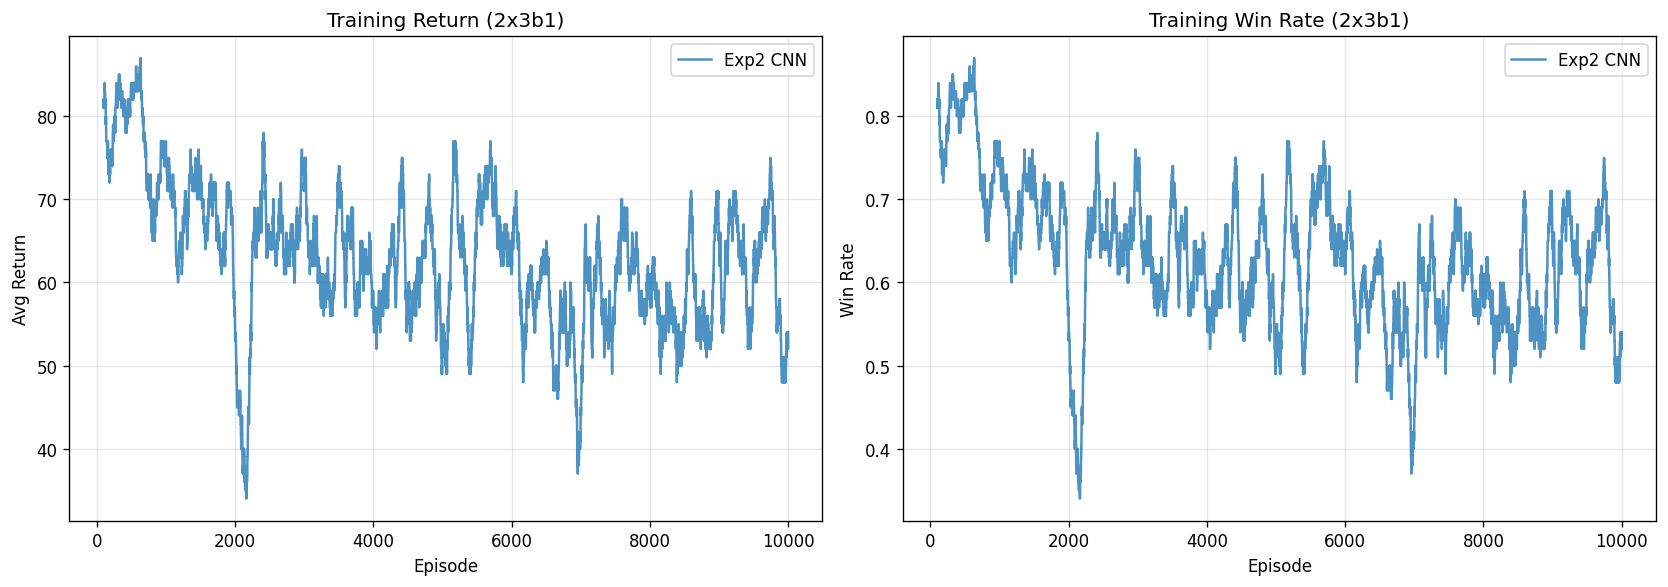

In [20]:
# --- 2x3b1 Learning Curves ---
training_csvs_2x3 = {
#    "Exp1 MLP": "results/exp1_mlp_2x3/exp1_mlp_2x3_training.csv",
    "Exp2 CNN": "results/exp2_cnn_2x3/exp2_cnn_2x3_training.csv",
    # "Exp3 Dyad (Agent A / MLP)": "results/exp3_dyad_2x3/agent_a_training.csv",
    # "Exp3 Dyad (Agent B / CNN)": "results/exp3_dyad_2x3/agent_b_training.csv",
}

# Filter to existing files only
available = {k: v for k, v in training_csvs_2x3.items() if os.path.exists(v)}
if available:
    plot_learning_curves(available, "results/visualizations/2x3", window=100)

    # Also show inline
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, csv_path in available.items():
        data = load_training_csv(csv_path)
        eps = data["episode"]
        ret_s = smooth(data["total_return"], 100)
        axes[0].plot(eps[99:], ret_s, label=name, alpha=0.8)
        wr_s = smooth([1.0 if s else 0.0 for s in data["success"]], 100)
        axes[1].plot(eps[99:], wr_s, label=name, alpha=0.8)

    axes[0].set(xlabel="Episode", ylabel="Avg Return", title="Training Return (2x3b1)")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set(xlabel="Episode", ylabel="Win Rate", title="Training Win Rate (2x3b1)")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No 2x3b1 training results found yet. Run experiments first.")

### 6.3 Evaluation Win Rate Comparison
Compare periodic evaluation win rates across experiments.

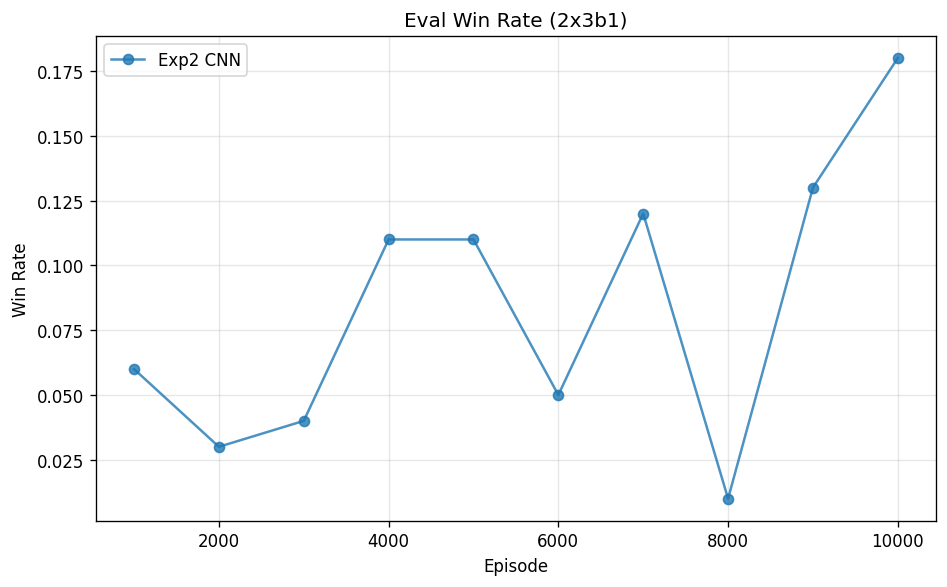

In [21]:
# --- Evaluation Win-Rate Comparison (2x3b1) ---
eval_jsons_2x3 = {
    # "Exp1 MLP": "results/exp1_mlp_2x3/exp1_mlp_2x3_eval.json",
    "Exp2 CNN": "results/exp2_cnn_2x3/exp2_cnn_2x3_eval.json",
    # "Exp3 Dyad (A)": "results/exp3_dyad_2x3/agent_a_eval.json",
    # "Exp3 Dyad (B)": "results/exp3_dyad_2x3/agent_b_eval.json",
}
avail_eval = {k: v for k, v in eval_jsons_2x3.items() if os.path.exists(v)}
if avail_eval:
    plot_eval_comparison(avail_eval, "results/visualizations/2x3")

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, json_path in avail_eval.items():
        evals = load_eval_json(json_path)
        ax.plot([e["episode"] for e in evals], [e["win_rate"] for e in evals],
                marker="o", label=name, alpha=0.8)
    ax.set(xlabel="Episode", ylabel="Win Rate", title="Eval Win Rate (2x3b1)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No 2x3b1 eval results found yet.")




### 6.2 Learning Curves — Netslide 3x3b1

In [ ]:
# --- 3x3b1 Learning Curves ---
training_csvs_3x3 = {
    "Exp1 MLP": "results/exp1_mlp_3x3/exp1_mlp_3x3_training.csv",
    "Exp2 CNN": "results/exp2_cnn_3x3/exp2_cnn_3x3_training.csv",
    "Exp3 Dyad (Agent A / MLP)": "results/exp3_dyad_3x3/agent_a_training.csv",
    "Exp3 Dyad (Agent B / CNN)": "results/exp3_dyad_3x3/agent_b_training.csv",
}

available = {k: v for k, v in training_csvs_3x3.items() if os.path.exists(v)}
if available:
    plot_learning_curves(available, "results/visualizations/3x3", window=100)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, csv_path in available.items():
        data = load_training_csv(csv_path)
        eps = data["episode"]
        ret_s = smooth(data["total_return"], 100)
        axes[0].plot(eps[99:], ret_s, label=name, alpha=0.8)
        wr_s = smooth([1.0 if s else 0.0 for s in data["success"]], 100)
        axes[1].plot(eps[99:], wr_s, label=name, alpha=0.8)

    axes[0].set(xlabel="Episode", ylabel="Avg Return", title="Training Return (3x3b1)")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set(xlabel="Episode", ylabel="Win Rate", title="Training Win Rate (3x3b1)")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No 3x3b1 training results found yet. Run experiments first.")

# --- Evaluation Win-Rate Comparison (3x3b1) ---

In [ ]:
eval_jsons_3x3 = {
    "Exp1 MLP": "results/exp1_mlp_3x3/exp1_mlp_3x3_eval.json",
    "Exp2 CNN": "results/exp2_cnn_3x3/exp2_cnn_3x3_eval.json",
    "Exp3 Dyad (A)": "results/exp3_dyad_3x3/agent_a_eval.json",
    "Exp3 Dyad (B)": "results/exp3_dyad_3x3/agent_b_eval.json",
}
avail_eval_3 = {k: v for k, v in eval_jsons_3x3.items() if os.path.exists(v)}
if avail_eval_3:
    plot_eval_comparison(avail_eval_3, "results/visualizations/3x3")

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, json_path in avail_eval_3.items():
        evals = load_eval_json(json_path)
        ax.plot([e["episode"] for e in evals], [e["win_rate"] for e in evals],
                marker="o", label=name, alpha=0.8)
    ax.set(xlabel="Episode", ylabel="Win Rate", title="Eval Win Rate (3x3b1)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No 3x3b1 eval results found yet.")

### 6.4 Final Summary Table
Aggregate best evaluation win rates from all experiments.

In [ ]:
all_eval_files = {
    # 2x3b1
    ("2x3b1", "Exp1 MLP"): "results/exp1_mlp_2x3/exp1_mlp_2x3_eval.json",
    ("2x3b1", "Exp2 CNN"): "results/exp2_cnn_2x3/exp2_cnn_2x3_eval.json",
    ("2x3b1", "Exp3 Dyad A"): "results/exp3_dyad_2x3/agent_a_eval.json",
    ("2x3b1", "Exp3 Dyad B"): "results/exp3_dyad_2x3/agent_b_eval.json",
    # 3x3b1
    ("3x3b1", "Exp1 MLP"): "results/exp1_mlp_3x3/exp1_mlp_3x3_eval.json",
    ("3x3b1", "Exp2 CNN"): "results/exp2_cnn_3x3/exp2_cnn_3x3_eval.json",
    ("3x3b1", "Exp3 Dyad A"): "results/exp3_dyad_3x3/agent_a_eval.json",
    ("3x3b1", "Exp3 Dyad B"): "results/exp3_dyad_3x3/agent_b_eval.json",
}

print(f"{'Puzzle':<8} {'Experiment':<18} {'Best WR':>8} {'Best Ret':>9} {'@ Episode':>10}")
print("-" * 58)
for (puzzle, exp_name), path in all_eval_files.items():
    if not os.path.exists(path):
        continue
    evals = load_eval_json(path)
    if not evals:
        continue
    best = max(evals, key=lambda e: e["win_rate"])
    print(f"{puzzle:<8} {exp_name:<18} {best['win_rate']:>8.3f} {best['avg_return']:>9.1f} {best['episode']:>10}")